SETUP & INSTALLATION

In [15]:
!pip install -q tensorflow openpyxl pandas numpy matplotlib
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from typing import Dict, List, Tuple, Optional
import warnings
warnings.filterwarnings('ignore')
from collections import deque

np.random.seed(42)
tf.random.set_seed(42)
print("All packages installed and imported successfully!")
print(f"TensorFlow version: {tf.__version__}")

All packages installed and imported successfully!
TensorFlow version: 2.19.0


CONFIG CLASS

In [16]:
class Config:
    """Central configuration for the adaptive controller."""
# Temporal parameters
  # time and memory
    SEQUENCE_LENGTH = 25 # gru sees last 25 timestamps
    SAMPLING_RATE = 20 # 20 samples per second
    FEATURE_COUNT = 7 # each timestamp has 7 parameters - position, velocity, acceleration, error, last pwm, load, dosturbance
# Control parameters
    DELTA_PWM_MAX = 5 # pwm jump cant be more than 15 steps at once
    PWM_MIN = 0
    PWM_MAX = 255 # 8 bit pwm
# Learning parameters
    BUFFER_SIZE = 10000 # system remembers 10000 experiences
    BATCH_SIZE = 32 # number of experiences it processes at once
    LEARNING_RATE = 1e-4
    UPDATE_INTERVAL = 5
    GRADIENT_CLIP_NORM = 1.0
# Loss function weights
    W_TRACKING = 1.0 # most prioritised
    W_COMFORT = 0.3
    W_SMOOTHNESS = 0.2
    W_ENERGY = 0.1
# Regularisation
    L2_LAMBDA = 1e-5
    DROPOUT_RATE = 0.2
print("Configuration loaded!")
print(f"   - Looking back: {Config.SEQUENCE_LENGTH} timesteps")
print(f"   - Max control change: ±{Config.DELTA_PWM_MAX} PWM per step")
print(f"   - Learning rate: {Config.LEARNING_RATE}")

Configuration loaded!
   - Looking back: 25 timesteps
   - Max control change: ±5 PWM per step
   - Learning rate: 0.0001


GRU NN

In [17]:
def build_gru_controller() -> keras.Model:
  inputs = layers.Input(
    shape=(Config.SEQUENCE_LENGTH, Config.FEATURE_COUNT),
    name='sensor_sequence'
)
# model expects input shaped like
  # [time, features]
  # (batch_size, 25, 7)
# First GRU layer - learns temporal patterns
  x = layers.GRU(
      64, # parallel memory processors
      return_sequences=True, # output smth at every timestep
      name='gru_temporal_features',
      kernel_regularizer=keras.regularizers.l2(Config.L2_LAMBDA)
  )(inputs)
  x = layers.Dropout(Config.DROPOUT_RATE)(x) #randomly disables 20% of neurons
# Second GRU layer - summarizing/compressing
  x = layers.GRU(
      32,
      return_sequences=False, # one decision only, not a decision per timestep
      name='gru_aggregate',
      kernel_regularizer=keras.regularizers.l2(Config.L2_LAMBDA)
  )(x)
  x = layers.Dropout(Config.DROPOUT_RATE)(x)
# Dense Layer - thinking layer - combines learned patterns, applies non linear logic and prepares for final output
  x = layers.Dense(
      16,
      activation='relu',
      name='dense_integration',
      kernel_regularizer=keras.regularizers.l2(Config.L2_LAMBDA)
  )(x)
# Output layer - produces 1 number, to control 1 actuator - meaning change in pwm
  outputs = layers.Dense(
      1,
      activation='tanh', # tanh outputs -1 to 1, we later scale this to x15
      name='delta_pwm_output'
  )(x)

# Build model
  model = keras.Model(inputs=inputs, outputs=outputs, name='GRU_Controller')

  return model
model = build_gru_controller()
print("Neural network created!")
model.summary()


for layer in model.layers:
    if hasattr(layer, 'kernel_initializer'):
        if 'output' in layer.name.lower():
            layer.kernel.assign(tf.zeros_like(layer.kernel))
            if hasattr(layer, 'bias'):
                layer.bias.assign(tf.zeros_like(layer.bias))
print("\noutput layer initialized to zero (neutral bias)")

Neural network created!


Model: "GRU_Controller"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sensor_sequence (InputLayer)    │ (None, 25, 7)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_temporal_features (GRU)     │ (None, 25, 64)         │        14,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 25, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_aggregate (GRU)             │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_integration (Dense)       │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ delta_pwm_output (Dense)        │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,969 (93.63 KB)

 Trainable params: 23,969 (93.63 KB)

 Non-trainable params: 0 (0.00 B)


output layer initialized to zero (neutral bias)


EXPERIENCE BUFFER

In [18]:
class ExperienceBuffer: # memory bank object
    """Memory system for storing past experiences."""
    def __init__(self, max_size: int = Config.BUFFER_SIZE):
        self.buffer = deque(maxlen=max_size) # memory which automatically deletes oldest experiences when full - fifo queue
        self.max_size = max_size
    def add(self, state_seq: np.ndarray, action: float,
        next_state: np.ndarray, metrics: Dict[str, float], smoothness: float = 0.0) -> None:
        experience = {
            'state_seq': state_seq.copy(),
            'action': action,
            'next_state': next_state.copy(),
            'metrics': metrics.copy()
        }
        experience['metrics']['smoothness'] = smoothness
        self.buffer.append(experience)
# state_seq: sensor readings over the last 25 timesteps
# action: the control signal we applied (like ΔPWM)
# next_state: what the sensors read after applying that action
# metrics: any extra info, e.g., tracking error, acceleration, comfort, energy

    # picks random experiences from memory to train model
    def sample(self, batch_size: int = Config.BATCH_SIZE) -> Optional[List[Dict]]:
        if len(self.buffer) < batch_size:
           return None
        indices = np.random.choice(len(self.buffer), batch_size, replace=False)
        return [self.buffer[i] for i in indices]
    def __len__(self) -> int: #returns number of experiences story now
        return len(self.buffer)
buffer = ExperienceBuffer()
print(f"Experience Buffer Created!")
print(f"   - Max capacity: {buffer.max_size:,} experiences")
print(f"   - Current size: {len(buffer)}")


Experience Buffer Created!
   - Max capacity: 10,000 experiences
   - Current size: 0


LOSS FUNCTION
Objectives:
- L_tracking - Minimise poisiton error
- L_comfort - minimise acceleartion
- L_smoothness - minimise control variation
- L_energy - minimise power consumption

Total loss = 1xtracking +0.3xcomfort +0.2xsmoothness + 0.1xenergy

In [19]:
def compute_physics_loss(model: keras.Model, batch: List[Dict],
                         training: bool = True) -> Tuple[tf.Tensor, Dict[str, float]]:

    # Unpack batch data
    state_seqs = np.array([exp['state_seq'] for exp in batch], dtype=np.float32)
    actual_actions = np.array([exp['action'] for exp in batch], dtype=np.float32)  # delta_pwm we applied
    next_states = np.array([exp['next_state'] for exp in batch], dtype=np.float32)
    metrics = [exp['metrics'] for exp in batch]

    # Model predicts what action it SHOULD take
    predicted_actions = model(state_seqs, training=training)
    predicted_actions = tf.squeeze(predicted_actions, axis=-1)  # Remove extra dimension

    # Extract features from next states (what happened AFTER our action)
    next_errors = next_states[:, 6]  # height_error is index 6 in state vector
    next_accels = next_states[:, 2]  # damper_acceleration is index 2
    next_currents = next_states[:, 3]  # motor_current is index 3
    next_pwms = next_states[:, 4]  # applied_pwm is index 4

    # Current state errors (for comparison)
    current_errors = state_seqs[:, -1, 6]  # Last timestep's error

    # LOSS 1: Tracking Error
    # Penalize actions that lead to large tracking errors in the next state
    L_tracking = tf.reduce_mean(tf.square(next_errors))

    # LOSS 2: Imitation Learning (learn from good experiences)
    # When the actual action resulted in low error, learn to replicate it
    error_quality = tf.exp(-10.0 * tf.abs(next_errors))  # High when next error is small
    L_imitation = tf.reduce_mean(
        error_quality * tf.square(predicted_actions - actual_actions)
    )

    # LOSS 3: Comfort (minimize acceleration/jerk)
    # Penalize actions that cause high accelerations
    L_comfort = tf.reduce_mean(tf.square(next_accels))

    # LOSS 4: Smoothness (penalize rapid control changes)
    # Extract smoothness penalties from metrics (computed during action)
    smoothness_vals = np.array([m.get('smoothness', 0.0) for m in metrics], dtype=np.float32)
    L_smoothness = tf.reduce_mean(smoothness_vals)

    # LOSS 5: Energy Efficiency
    # Penalize high current draw (power = current × voltage, voltage ∝ PWM)
    L_energy = tf.reduce_mean(next_currents * next_pwms) / 255.0

    # COMBINED LOSS with weighted priorities
    total_loss = (
        Config.W_TRACKING * (L_tracking + 0.3 * L_imitation) +  # Track target, learn from success
        Config.W_COMFORT * L_comfort +                          # Smooth ride
        Config.W_SMOOTHNESS * L_smoothness +                    # Smooth control
        Config.W_ENERGY * L_energy                              # Efficient operation
    )

    # Return loss and detailed breakdown
    loss_components = {
        'total': float(total_loss.numpy()),
        'tracking': float(L_tracking.numpy()),
        'imitation': float(L_imitation.numpy()),
        'comfort': float(L_comfort.numpy()),
        'smoothness': float(L_smoothness.numpy()),
        'energy': float(L_energy.numpy())
    }

    return total_loss, loss_components

print("Loss Function Defined!")
print("\nObjective Priorities:")
print(f"  1. Tracking Error:  {Config.W_TRACKING}")
print(f"  2. Comfort:         {Config.W_COMFORT}")
print(f"  3. Smoothness:      {Config.W_SMOOTHNESS}")
print(f"  4. Energy:          {Config.W_ENERGY}")
print("\n Loss now uses model predictions to guide learning!")

Loss Function Defined!

Objective Priorities:
  1. Tracking Error:  1.0
  2. Comfort:         0.3
  3. Smoothness:      0.2
  4. Energy:          0.1

 Loss now uses model predictions to guide learning!


ADAPTIVE CONTROLLER

In [20]:
class AdaptiveController:
    """full adaptive control system"""

    def __init__(self):
        self.model = build_gru_controller()

        # optimiser - model learns
        self.optimizer = keras.optimizers.Adam(
            learning_rate=Config.LEARNING_RATE,
            clipnorm=Config.GRADIENT_CLIP_NORM
        )
        # create memory buffer
        self.buffer = ExperienceBuffer()
        # state tracking
        self.current_pwm = None        # start at mid-range
        self.state_history = deque(maxlen=Config.SEQUENCE_LENGTH)  # remember last 25 states
        self.timestep = 0
        # log performance
        self.loss_history = []

        print("=" * 70)
        print("adaptive controller initialized")
        print(f"   neural network params: {self.model.count_params():,}")
        print(f"   memory window: {Config.SEQUENCE_LENGTH} timesteps")
        print(f"   learning rate: {Config.LEARNING_RATE}")
        print("=" * 70)

    def initialize_history(self, initial_states: List[np.ndarray], initial_pwm: float) -> None:
        for state in initial_states[:Config.SEQUENCE_LENGTH]:
            self.state_history.append(state)  # ❌ WRONG INDENTATION
        self.current_pwm = initial_pwm
        print(f"state history initialized ({len(self.state_history)} samples)")
        print(f"initial PWM set to: {self.current_pwm:.1f}")

    def act(self, current_state: Dict[str, float]) -> int:
        state_vector = np.array([
            current_state['ride_height'],
            current_state['damper_velocity'],
            current_state['damper_acceleration'],
            current_state['motor_current'],
            current_state['applied_pwm'],
            current_state['target_ride_height'],
            current_state['height_error']
        ], dtype=np.float32)

        self.state_history.append(state_vector)

        state_sequence = np.array(self.state_history).reshape(
            1, Config.SEQUENCE_LENGTH, Config.FEATURE_COUNT
        )

        delta_pwm_normalized = self.model.predict(state_sequence, verbose=0)[0, 0]

        if self.timestep < 500:
            exploration_noise = np.random.normal(0, 0.3) * (1.0 - self.timestep / 500)
            delta_pwm_normalized = np.clip(delta_pwm_normalized + exploration_noise, -1.0, 1.0)

        delta_pwm = delta_pwm_normalized * Config.DELTA_PWM_MAX

        if self.current_pwm < 30 and delta_pwm < 0:
            delta_pwm = delta_pwm * 0.2
        elif self.current_pwm > 225 and delta_pwm > 0:
            delta_pwm = delta_pwm * 0.2

        new_pwm = self.current_pwm + delta_pwm
        new_pwm = np.clip(new_pwm, Config.PWM_MIN, Config.PWM_MAX)

        self.current_pwm = new_pwm

        if self.timestep % 20 == 0 and self.current_pwm < 20:
            print(f"  step {self.timestep}: PWM critically low ({self.current_pwm:.1f}), adding recovery boost")
            self.current_pwm = min(self.current_pwm + 10, 50)

        return int(self.current_pwm)

    def learn(self, current_state: Dict[str, float], action: float,
              next_state: Dict[str, float], metrics: Dict[str, float]) -> None:
        # store experience in buffer
        self.buffer.add(
            state_seq=np.array(self.state_history),
            action=action,
            smoothness=abs(action) if self.timestep > 0 else 0.0,
            next_state=np.array([
                next_state['ride_height'],
                next_state['damper_velocity'],
                next_state['damper_acceleration'],
                next_state['motor_current'],
                next_state['applied_pwm'],
                next_state['target_ride_height'],
                next_state['height_error']
            ]),
            metrics=metrics
        )

        # update model every UPDATE_INTERVAL steps
        if self.timestep % Config.UPDATE_INTERVAL == 0 and len(self.buffer) >= Config.BATCH_SIZE:
            # sample random batch
            batch = self.buffer.sample()

            # compute loss and gradients
            with tf.GradientTape() as tape:
                loss, loss_components = compute_physics_loss(self.model, batch, training=True)
            gradients = tape.gradient(loss, self.model.trainable_variables)

            # apply gradients to model
            self.optimizer.apply_gradients(zip(gradients, self.model.trainable_variables))

            # log loss
            self.loss_history.append({'timestep': self.timestep, **loss_components})

            # print progress every 10 updates
            if self.timestep % (Config.UPDATE_INTERVAL * 10) == 0:
                print(f"step {self.timestep:6d} | loss: {loss_components['total']:.4f} | "
                      f"tracking: {loss_components['tracking']:.4f}")

        # increase timestep
        self.timestep += 1

print("controller class defined!")


controller class defined!


DATA LOADING

In [21]:
from google.colab import files

# upload your excel file
print("Please upload your 'your_actuator_data.xlsx' file:")
uploaded = files.upload()  # open file dialog, store file content

# load the data
def load_data(filename):
    """load and validate excel data"""
    print(f"\n loading {filename}...")
    df = pd.read_excel(filename)  # read excel into dataframe

    # compute derived feature
    df['height_error'] = df['target_ride_height'] - df['ride_height']  # target - actual
    print(f" data loaded: {len(df)} samples")
    print(f"   duration: {len(df) / Config.SAMPLING_RATE:.1f} seconds")

    return df

# load your file
df = load_data(list(uploaded.keys())[0])  # take first uploaded file

# show first few rows
print("\n first 5 rows:")
print(df.head())  # quick check

# show statistics
print("\n data statistics:")
print(df.describe())  # mean, std, min, max etc


Please upload your 'your_actuator_data.xlsx' file:


Saving your_actuator_data_demo_variation.xlsx to your_actuator_data_demo_variation.xlsx

 loading your_actuator_data_demo_variation.xlsx...
 data loaded: 700 samples
   duration: 35.0 seconds

 first 5 rows:
   ride_height  damper_velocity  damper_acceleration  motor_current  \
0     0.150000            0.000             0.000000       2.663345   
1     0.169015            0.554             7.606092       2.376610   
2     0.185714            0.420            -0.926739       2.555605   
3     0.195346            0.219            -2.826266       2.577690   
4     0.200075            0.070            -1.961671       2.445274   

   applied_pwm  target_ride_height  height_error  
0          122            0.152122      0.002122  
1          144            0.152602     -0.016413  
2          127            0.150806     -0.034908  
3          121            0.154602     -0.040744  
4          112            0.157585     -0.042490  

 data statistics:
       ride_height  damper_velocity  dam

RUN SIMULATION

In [22]:
def run_simulation(df, warmup_steps=100):
    """run the adaptive control simulation"""

    print("starting simulation")
    print("\ndataset statistics:")
    print(f"  first PWM: {df['applied_pwm'].iloc[0]:.1f}")
    print(f"  mean PWM:  {df['applied_pwm'].mean():.1f}")
    print(f"  PWM range: {df['applied_pwm'].min():.1f} - {df['applied_pwm'].max():.1f}")

    controller = AdaptiveController()

    print(f"\ninitializing with first {Config.SEQUENCE_LENGTH} samples...")
    initial_states = []
    for i in range(Config.SEQUENCE_LENGTH):
        row = df.iloc[i]
        state_vector = np.array([
            row['ride_height'], row['damper_velocity'], row['damper_acceleration'],
            row['motor_current'], row['applied_pwm'], row['target_ride_height'],
            row['height_error']
        ], dtype=np.float32)
        initial_states.append(state_vector)

    initial_pwm = df['applied_pwm'].iloc[Config.SEQUENCE_LENGTH - 1]
    controller.initialize_history(initial_states, initial_pwm)

    print("\npre-training on first 50 experiences...")
    for i in range(Config.SEQUENCE_LENGTH, min(Config.SEQUENCE_LENGTH + 50, len(df) - 1)):
        row_curr = df.iloc[i]
        row_next = df.iloc[i + 1]

        state_seq = np.array([initial_states[j] for j in range(Config.SEQUENCE_LENGTH)])
        action = row_next['applied_pwm'] - row_curr['applied_pwm']

        next_state = np.array([
            row_next['ride_height'], row_next['damper_velocity'],
            row_next['damper_acceleration'], row_next['motor_current'],
            row_next['applied_pwm'], row_next['target_ride_height'],
            row_next['height_error']
        ])

        metrics = {
            'error': row_next['height_error'],
            'acceleration': row_next['damper_acceleration'],
            'current': row_next['motor_current'],
            'pwm': row_next['applied_pwm'],
            'smoothness': abs(action)
        }

        controller.buffer.add(state_seq, action, next_state, metrics)

        initial_states.pop(0)
        initial_states.append(next_state)

    if len(controller.buffer) >= Config.BATCH_SIZE:
        for _ in range(10):
            batch = controller.buffer.sample()
            with tf.GradientTape() as tape:
                loss, _ = compute_physics_loss(controller.model, batch, training=True)
            grads = tape.gradient(loss, controller.model.trainable_variables)
            controller.optimizer.apply_gradients(zip(grads, controller.model.trainable_variables))
        print(f"pre-training complete: {len(controller.buffer)} experiences stored")

    print(f"\nrunning control loop ({len(df) - Config.SEQUENCE_LENGTH} steps)...")
    results = []

    debug_count = 0
    print("\nfirst 20 steps:")
    print("step | error(mm) | PWM | delta")
    print("-" * 40)

    for i in range(Config.SEQUENCE_LENGTH, len(df)):
        row = df.iloc[i]

        current_state = {
            'ride_height': row['ride_height'],
            'damper_velocity': row['damper_velocity'],
            'damper_acceleration': row['damper_acceleration'],
            'motor_current': row['motor_current'],
            'applied_pwm': controller.current_pwm,
            'target_ride_height': row['target_ride_height'],
            'height_error': row['height_error']
        }

        old_pwm = controller.current_pwm
        pwm_command = controller.act(current_state)
        delta_pwm = pwm_command - old_pwm

        if debug_count < 20:
            print(f"{i:4d} | {current_state['height_error']*1000:7.2f} | "
                  f"{pwm_command:3d} | {delta_pwm:+6.2f}")
            debug_count += 1

        metrics = {
            'error': current_state['height_error'],
            'acceleration': current_state['damper_acceleration'],
            'current': current_state['motor_current'],
            'pwm': pwm_command,
            'smoothness': abs(delta_pwm)
        }

        if i >= warmup_steps and i + 1 < len(df):
            next_row = df.iloc[i + 1]
            next_state = {
                'ride_height': next_row['ride_height'],
                'damper_velocity': next_row['damper_velocity'],
                'damper_acceleration': next_row['damper_acceleration'],
                'motor_current': next_row['motor_current'],
                'applied_pwm': pwm_command,
                'target_ride_height': next_row['target_ride_height'],
                'height_error': next_row['height_error']
            }

            controller.learn(current_state, delta_pwm, next_state, metrics)

        results.append({
            'timestep': i,
            'time_sec': i / Config.SAMPLING_RATE,
            'ride_height': current_state['ride_height'],
            'target': current_state['target_ride_height'],
            'error': current_state['height_error'],
            'pwm_command': pwm_command
        })

    print("\nsimulation complete!")
    results_df = pd.DataFrame(results)

    stuck_at_min = sum(1 for r in results if r['pwm_command'] == 0)
    stuck_at_max = sum(1 for r in results if r['pwm_command'] == 255)
    print(f"\ndiagnostics:")
    print(f"  steps at PWM=0:   {stuck_at_min}/{len(results)}")
    print(f"  steps at PWM=255: {stuck_at_max}/{len(results)}")

    if stuck_at_min > len(results) * 0.3:
        print("\n  WARNING: controller stuck at minimum!")
    if stuck_at_max > len(results) * 0.3:
        print("\n  WARNING: controller stuck at maximum!")

    return results_df, controller
# RUN THE SIMULATION
results_df, controller = run_simulation(df, warmup_steps=100)

starting simulation

dataset statistics:
  first PWM: 122.0
  mean PWM:  125.7
  PWM range: 95.0 - 161.0
adaptive controller initialized
   neural network params: 23,969
   memory window: 25 timesteps
   learning rate: 0.0001

initializing with first 25 samples...
state history initialized (25 samples)
initial PWM set to: 125.0

pre-training on first 50 experiences...
pre-training complete: 50 experiences stored

running control loop (675 steps)...

first 20 steps:
step | error(mm) | PWM | delta
----------------------------------------
  25 |  -40.18 | 127 |  +2.00
  26 |  -43.01 | 128 |  +0.67
  27 |  -43.33 | 129 |  +0.71
  28 |  -44.07 | 131 |  +1.12
  29 |  -42.57 | 132 |  +0.96
  30 |  -48.37 | 135 |  +2.94
  31 |  -47.19 | 137 |  +1.77
  32 |  -50.21 | 138 |  +0.34
  33 |  -50.33 | 141 |  +2.50
  34 |  -51.01 | 144 |  +2.26
  35 |  -55.75 | 147 |  +2.92
  36 |  -52.68 | 149 |  +1.83
  37 |  -52.24 | 150 |  +0.01
  38 |  -56.79 | 151 |  +0.38
  39 |  -54.43 | 154 |  +2.36
  40 |  

VIZUALISATION

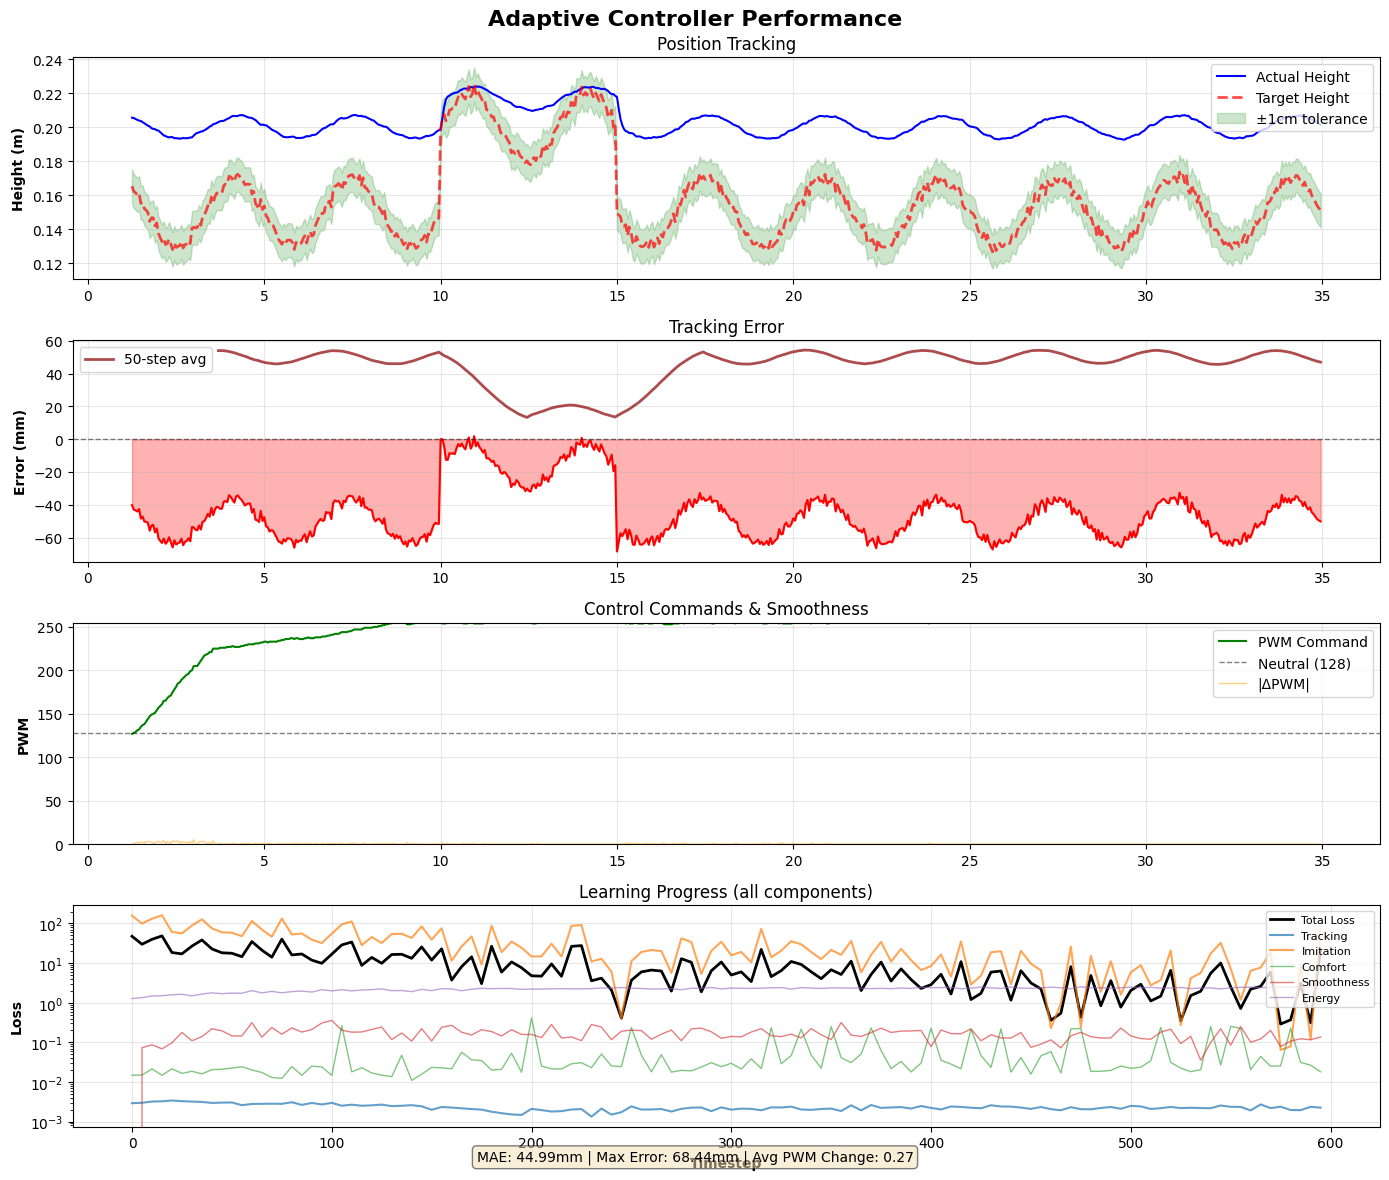

In [23]:
def plot_results(results_df, controller):
    """Plot controller performance"""

    fig, axes = plt.subplots(4, 1, figsize=(14, 12))
    fig.suptitle('Adaptive Controller Performance', fontsize=16, fontweight='bold')

    time = results_df['time_sec'].values

    axes[0].plot(time, results_df['ride_height'], label='Actual Height',
                 linewidth=1.5, color='blue')
    axes[0].plot(time, results_df['target'], label='Target Height',
                 linestyle='--', linewidth=2, color='red', alpha=0.7)
    axes[0].fill_between(time,
                          results_df['target'] - 0.01,
                          results_df['target'] + 0.01,
                          alpha=0.2, color='green', label='±1cm tolerance')
    axes[0].set_ylabel('Height (m)', fontweight='bold')
    axes[0].legend(loc='best')
    axes[0].grid(True, alpha=0.3)
    axes[0].set_title('Position Tracking')

    axes[1].plot(time, results_df['error'] * 1000, color='red', linewidth=1.5)
    axes[1].axhline(0, color='black', linestyle='--', alpha=0.5, linewidth=1)
    axes[1].fill_between(time, 0, results_df['error'] * 1000, alpha=0.3, color='red')

    window = 50
    if len(results_df) > window:
        rolling_error = results_df['error'].abs().rolling(window).mean() * 1000
        axes[1].plot(time, rolling_error, color='darkred', linewidth=2,
                     label=f'{window}-step avg', alpha=0.7)
        axes[1].legend(loc='best')

    axes[1].set_ylabel('Error (mm)', fontweight='bold')
    axes[1].grid(True, alpha=0.3)
    axes[1].set_title('Tracking Error')

    axes[2].plot(time, results_df['pwm_command'], color='green', linewidth=1.5, label='PWM Command')
    axes[2].axhline(128, color='black', linestyle='--', alpha=0.5, linewidth=1,
                    label='Neutral (128)')

    pwm_change = results_df['pwm_command'].diff().abs()
    axes[2].plot(time[1:], pwm_change.values[1:], color='orange',
                 alpha=0.5, linewidth=1, label='|ΔPWM|')

    axes[2].set_ylabel('PWM', fontweight='bold')
    axes[2].set_ylim([0, 255])
    axes[2].legend(loc='best')
    axes[2].grid(True, alpha=0.3)
    axes[2].set_title('Control Commands & Smoothness')

    if controller.loss_history and len(controller.loss_history) > 0:
        loss_df = pd.DataFrame(controller.loss_history)
        timesteps = loss_df['timestep'].values

        axes[3].plot(timesteps, loss_df['total'], label='Total Loss',
                     linewidth=2, color='black')
        axes[3].plot(timesteps, loss_df['tracking'], label='Tracking',
                     alpha=0.7, linewidth=1.5)
        axes[3].plot(timesteps, loss_df.get('imitation', [0]*len(loss_df)),
                     label='Imitation', alpha=0.7, linewidth=1.5)
        axes[3].plot(timesteps, loss_df['comfort'], label='Comfort',
                     alpha=0.6, linewidth=1)
        axes[3].plot(timesteps, loss_df['smoothness'], label='Smoothness',
                     alpha=0.6, linewidth=1)
        axes[3].plot(timesteps, loss_df['energy'], label='Energy',
                     alpha=0.6, linewidth=1)

        axes[3].set_ylabel('Loss', fontweight='bold')
        axes[3].set_xlabel('Timestep', fontweight='bold')
        axes[3].legend(loc='upper right', fontsize=8)
        axes[3].grid(True, alpha=0.3)
        axes[3].set_title('Learning Progress (all components)')
        axes[3].set_yscale('log')
    else:
        axes[3].text(0.5, 0.5, 'No learning data\n(warmup period or no updates yet)',
                     ha='center', va='center', fontsize=14, color='red')
        axes[3].set_xlabel('Timestep', fontweight='bold')
        axes[3].set_title('Learning Progress')

    plt.tight_layout()

    mae_mm = results_df['error'].abs().mean() * 1000
    max_error_mm = results_df['error'].abs().max() * 1000
    avg_pwm_change = results_df['pwm_command'].diff().abs().mean()

    stats_text = f"MAE: {mae_mm:.2f}mm | Max Error: {max_error_mm:.2f}mm | Avg PWM Change: {avg_pwm_change:.2f}"
    fig.text(0.5, 0.02, stats_text, ha='center', fontsize=10,
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.show()

plot_results(results_df, controller)


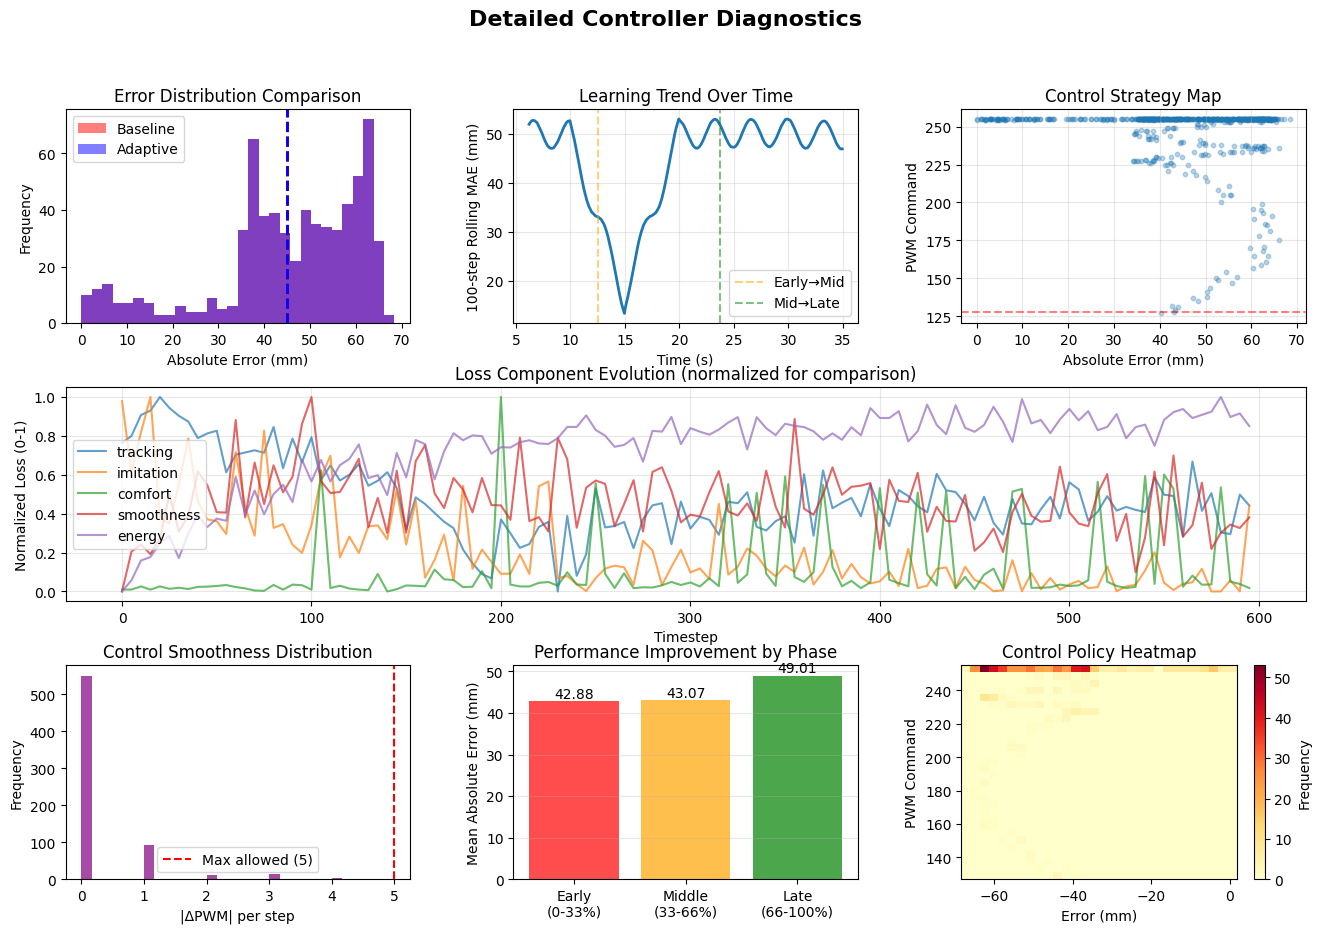

In [24]:
def plot_detailed_diagnostics(results_df, controller, df_original):
    """Detailed analysis plots"""

    fig = plt.figure(figsize=(16, 10))
    gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

    ax1 = fig.add_subplot(gs[0, 0])
    original_error = df_original['height_error'].iloc[Config.SEQUENCE_LENGTH:].abs() * 1000
    adaptive_error = results_df['error'].abs() * 1000

    ax1.hist(original_error, bins=30, alpha=0.5, label='Baseline', color='red')
    ax1.hist(adaptive_error, bins=30, alpha=0.5, label='Adaptive', color='blue')
    ax1.set_xlabel('Absolute Error (mm)')
    ax1.set_ylabel('Frequency')
    ax1.legend()
    ax1.set_title('Error Distribution Comparison')
    ax1.axvline(original_error.mean(), color='red', linestyle='--', linewidth=2)
    ax1.axvline(adaptive_error.mean(), color='blue', linestyle='--', linewidth=2)

    ax2 = fig.add_subplot(gs[0, 1])
    window = 100
    rolling_mae = results_df['error'].abs().rolling(window).mean() * 1000
    ax2.plot(results_df['time_sec'], rolling_mae, linewidth=2)
    ax2.set_xlabel('Time (s)')
    ax2.set_ylabel(f'{window}-step Rolling MAE (mm)')
    ax2.set_title('Learning Trend Over Time')
    ax2.grid(True, alpha=0.3)

    n = len(results_df)
    ax2.axvline(results_df['time_sec'].iloc[n//3], color='orange',
                linestyle='--', alpha=0.5, label='Early→Mid')
    ax2.axvline(results_df['time_sec'].iloc[2*n//3], color='green',
                linestyle='--', alpha=0.5, label='Mid→Late')
    ax2.legend()

    ax3 = fig.add_subplot(gs[0, 2])
    ax3.scatter(results_df['error'].abs() * 1000, results_df['pwm_command'],
                alpha=0.3, s=10)
    ax3.set_xlabel('Absolute Error (mm)')
    ax3.set_ylabel('PWM Command')
    ax3.set_title('Control Strategy Map')
    ax3.axhline(128, color='red', linestyle='--', alpha=0.5)
    ax3.grid(True, alpha=0.3)

    ax4 = fig.add_subplot(gs[1, :])
    if controller.loss_history and len(controller.loss_history) > 0:
        loss_df = pd.DataFrame(controller.loss_history)

        for component in ['tracking', 'imitation', 'comfort', 'smoothness', 'energy']:
            if component in loss_df.columns:
                normalized = (loss_df[component] - loss_df[component].min()) / \
                            (loss_df[component].max() - loss_df[component].min() + 1e-8)
                ax4.plot(loss_df['timestep'], normalized, label=component, alpha=0.7)

        ax4.set_xlabel('Timestep')
        ax4.set_ylabel('Normalized Loss (0-1)')
        ax4.set_title('Loss Component Evolution (normalized for comparison)')
        ax4.legend()
        ax4.grid(True, alpha=0.3)

    ax5 = fig.add_subplot(gs[2, 0])
    pwm_diff = results_df['pwm_command'].diff().abs()
    ax5.hist(pwm_diff.dropna(), bins=30, color='purple', alpha=0.7)
    ax5.set_xlabel('|ΔPWM| per step')
    ax5.set_ylabel('Frequency')
    ax5.set_title('Control Smoothness Distribution')
    ax5.axvline(Config.DELTA_PWM_MAX, color='red', linestyle='--',
                label=f'Max allowed ({Config.DELTA_PWM_MAX})')
    ax5.legend()

    ax6 = fig.add_subplot(gs[2, 1])
    n = len(results_df)
    phases = ['Early\n(0-33%)', 'Middle\n(33-66%)', 'Late\n(66-100%)']
    phase_errors = [
        results_df.iloc[:n//3]['error'].abs().mean() * 1000,
        results_df.iloc[n//3:2*n//3]['error'].abs().mean() * 1000,
        results_df.iloc[2*n//3:]['error'].abs().mean() * 1000
    ]

    bars = ax6.bar(phases, phase_errors, color=['red', 'orange', 'green'], alpha=0.7)
    ax6.set_ylabel('Mean Absolute Error (mm)')
    ax6.set_title('Performance Improvement by Phase')
    ax6.grid(True, alpha=0.3, axis='y')

    for bar, val in zip(bars, phase_errors):
        ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                 f'{val:.2f}', ha='center', va='bottom')

    ax7 = fig.add_subplot(gs[2, 2])
    ax7.hist2d(results_df['error'] * 1000, results_df['pwm_command'],
               bins=30, cmap='YlOrRd')
    ax7.set_xlabel('Error (mm)')
    ax7.set_ylabel('PWM Command')
    ax7.set_title('Control Policy Heatmap')
    plt.colorbar(ax7.collections[0], ax=ax7, label='Frequency')

    plt.suptitle('Detailed Controller Diagnostics', fontsize=16, fontweight='bold')
    plt.show()

plot_detailed_diagnostics(results_df, controller, df)

PERFORMANCE METRICS

In [25]:
def print_report(results_df, controller):
    """Print performance metrics."""

    print(" PERFORMANCE REPORT")

    # Tracking
    mae = results_df['error'].abs().mean()
    rmse = np.sqrt((results_df['error'] ** 2).mean())
    max_error = results_df['error'].abs().max()

    print("\n TRACKING PERFORMANCE:")
    print(f"   Mean Absolute Error:  {mae:.6f} m")
    print(f"   RMS Error:            {rmse:.6f} m")
    print(f"   Maximum Error:        {max_error:.6f} m")

    # Control
    pwm_var = results_df['pwm_command'].diff().abs().mean()

    print("\n CONTROL QUALITY:")
    print(f"   Mean PWM Variation:   {pwm_var:.2f}")

    # Learning
    print("\n LEARNING STATS:")
    print(f"   Total Timesteps:      {controller.timestep:,}")
    print(f"   Experiences Stored:   {len(controller.buffer):,}")
    print(f"   Learning Updates:     {len(controller.loss_history):,}")

    if controller.loss_history:
        final_loss = controller.loss_history[-1]
        print(f"   Final Loss:           {final_loss['total']:.4f}")

# PRINT IT!
print_report(results_df, controller)

 PERFORMANCE REPORT

 TRACKING PERFORMANCE:
   Mean Absolute Error:  0.044986 m
   RMS Error:            0.047881 m
   Maximum Error:        0.068444 m

 CONTROL QUALITY:
   Mean PWM Variation:   0.27

 LEARNING STATS:
   Total Timesteps:      599
   Experiences Stored:   649
   Learning Updates:     120
   Final Loss:           21.6647
